# 03 — EDA: T-100 International

Monthly aggregate traffic and capacity for international routes at IAD, DCA, BWI.
Granularity: one row per carrier × origin × destination × month.
No delay data — use on-time (02) for that.

**Note on direction:** T-100 reports each segment once from the operating carrier's perspective. `ORIGIN in airports` = outbound departures; `DEST in airports` = inbound arrivals. Passenger counts use outbound only to avoid double-counting the same round-trip route. Route discovery (which destinations are served) uses both directions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from config import PROCESSED_DATA_PATH

sns.set_theme(style='whitegrid', palette='muted')
AIRPORTS = ['IAD', 'DCA', 'BWI']
AIRPORT_NAMES = {'IAD': 'Dulles (IAD)', 'DCA': 'Reagan (DCA)', 'BWI': 'BWI'}
COLORS = {'IAD': '#1f77b4', 'DCA': '#ff7f0e', 'BWI': '#2ca02c'}

df = pd.read_parquet(PROJECT_ROOT / PROCESSED_DATA_PATH / 't100_intl_dmv.parquet')

# Scheduled service only (CLASS=F) — excludes charter (L), military (G), cargo-only (P)
sched = df[df['CLASS'] == 'F'].copy()

# Outbound: flights departing from our airports to international destinations
outbound = sched[sched['ORIGIN'].isin(AIRPORTS)].copy()

print(f'Total rows (all classes): {len(df):,}')
print(f'Scheduled service rows:   {len(sched):,}')
print(f'Outbound scheduled rows:  {len(outbound):,}')
print()
print('CLASS breakdown (passengers):')
print(df.groupby('CLASS')['PASSENGERS'].sum().sort_values(ascending=False).apply(lambda x: f'{x:,.0f}'))

Total rows (all classes): 35,846
Scheduled service rows:   31,435
Outbound scheduled rows:  15,450

CLASS breakdown (passengers):
CLASS
F    95,264,029
L       354,427
P           267
G             0
Name: PASSENGERS, dtype: object


## 1. International passenger volume by airport × year

All scheduled outbound international passengers, 2015–2025.

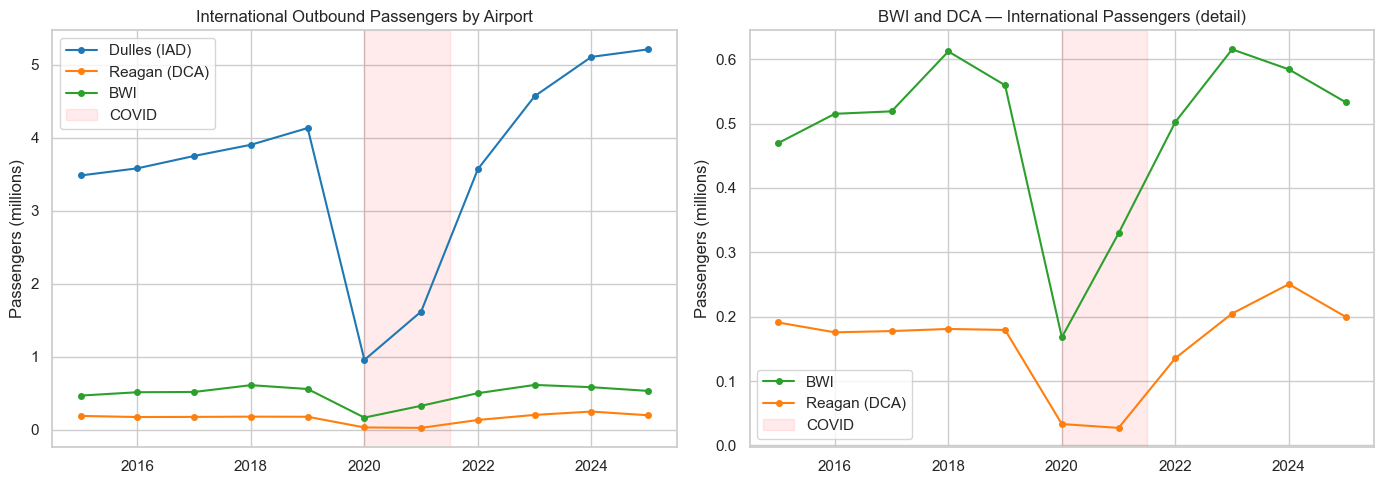


Outbound passengers (M):
ORIGIN   BWI   DCA   IAD
YEAR                    
2015    0.47  0.19  3.48
2016    0.52  0.18  3.58
2017    0.52  0.18  3.75
2018    0.61  0.18  3.90
2019    0.56  0.18  4.13
2020    0.17  0.03  0.96
2021    0.33  0.03  1.62
2022    0.50  0.14  3.57
2023    0.62  0.20  4.57
2024    0.58  0.25  5.11
2025    0.53  0.20  5.21


In [2]:
pax_yr = (
    outbound[outbound['YEAR'] <= 2025]
    .groupby(['YEAR', 'ORIGIN'])['PASSENGERS']
    .sum()
    .unstack()
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute volume
ax = axes[0]
for airport in AIRPORTS:
    ax.plot(pax_yr.index, pax_yr[airport] / 1e6, marker='o', ms=4,
            label=AIRPORT_NAMES[airport], color=COLORS[airport])
ax.axvspan(2020, 2021.5, alpha=0.08, color='red', label='COVID')
ax.set_title('International Outbound Passengers by Airport')
ax.set_ylabel('Passengers (millions)')
ax.set_xlabel('')
ax.legend()

# BWI + DCA only (IAD dwarfs them)
ax = axes[1]
for airport in ['BWI', 'DCA']:
    ax.plot(pax_yr.index, pax_yr[airport] / 1e6, marker='o', ms=4,
            label=AIRPORT_NAMES[airport], color=COLORS[airport])
ax.axvspan(2020, 2021.5, alpha=0.08, color='red', label='COVID')
ax.set_title('BWI and DCA — International Passengers (detail)')
ax.set_ylabel('Passengers (millions)')
ax.set_xlabel('')
ax.legend()

plt.tight_layout()
plt.show()

print('\nOutbound passengers (M):')
print((pax_yr / 1e6).round(2))

## 2. Load factor (passengers / seats) by airport × year

Weighted average load factor: total passengers / total seats across all outbound scheduled flights. Shows how efficiently capacity is being used.

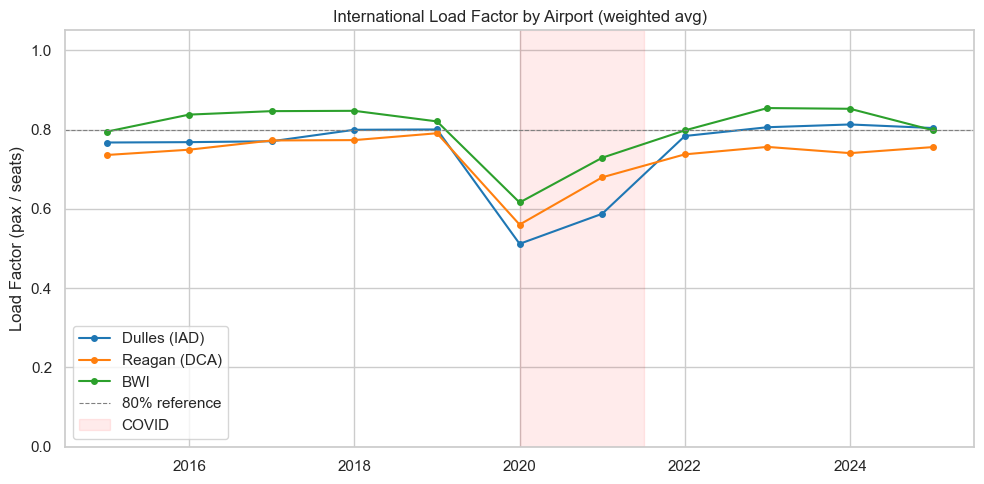


Weighted load factor:
ORIGIN    BWI    DCA    IAD
YEAR                       
2015    0.795  0.736  0.767
2016    0.838  0.749  0.768
2017    0.846  0.772  0.770
2018    0.847  0.773  0.799
2019    0.821  0.791  0.800
2020    0.616  0.560  0.512
2021    0.729  0.680  0.588
2022    0.798  0.737  0.784
2023    0.854  0.756  0.806
2024    0.852  0.741  0.813
2025    0.798  0.756  0.804


In [3]:
valid = outbound[outbound['SEATS'] > 0].copy()
valid['load_factor'] = valid['PASSENGERS'] / valid['SEATS']

# Weighted mean LF: sum(pax) / sum(seats) per year per airport
lf_num = valid[valid['YEAR'] <= 2025].groupby(['YEAR', 'ORIGIN'])['PASSENGERS'].sum()
lf_den = valid[valid['YEAR'] <= 2025].groupby(['YEAR', 'ORIGIN'])['SEATS'].sum()
lf = (lf_num / lf_den).unstack().fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
for airport in AIRPORTS:
    ax.plot(lf.index, lf[airport], marker='o', ms=4,
            label=AIRPORT_NAMES[airport], color=COLORS[airport])
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, label='80% reference')
ax.axvspan(2020, 2021.5, alpha=0.08, color='red', label='COVID')
ax.set_title('International Load Factor by Airport (weighted avg)')
ax.set_ylabel('Load Factor (pax / seats)')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

print('\nWeighted load factor:')
print(lf.round(3))

## 3. DCA perimeter rule — what international routes exist?

DCA is restricted to destinations within 1,250 miles by the High Density Rule (perimeter rule). International routes from DCA are essentially limited to Canada and the nearby Caribbean.

In [4]:
dca_out = outbound[outbound['ORIGIN'] == 'DCA']

print('DCA international outbound: total pax by destination country')
dca_countries = dca_out.groupby('DEST_COUNTRY_NAME')['PASSENGERS'].sum().sort_values(ascending=False)
print(dca_countries.apply(lambda x: f'{x:,.0f}'))

print('\nDCA routes (unique carrier × destination):')
dca_routes = dca_out.groupby(['DEST', 'DEST_CITY_NAME', 'UNIQUE_CARRIER_NAME'])['PASSENGERS'].sum().reset_index()
print(dca_routes.sort_values('PASSENGERS', ascending=False).to_string(index=False))

DCA international outbound: total pax by destination country
DEST_COUNTRY_NAME
Canada         1,502,794
The Bahamas      210,388
Bermuda           56,996
Name: PASSENGERS, dtype: object

DCA routes (unique carrier × destination):
DEST        DEST_CITY_NAME                UNIQUE_CARRIER_NAME  PASSENGERS
 YYZ       Toronto, Canada         Sky Regional Airlines Inc.    425078.0
 YUL      Montreal, Canada                   Jazz Aviation LP    339530.0
 YYZ       Toronto, Canada                   Jazz Aviation LP    281193.0
 YYZ       Toronto, Canada                  PSA Airlines Inc.    179818.0
 YOW        Ottawa, Canada                   Jazz Aviation LP    149441.0
 NAS   Nassau, The Bahamas             American Airlines Inc.    127902.0
 YYZ       Toronto, Canada        Air Wisconsin Airlines Corp     55656.0
 BDA     Hamilton, Bermuda             American Airlines Inc.     54181.0
 YYZ       Toronto, Canada              Trans States Airlines     53668.0
 NAS   Nassau, The Bahamas    

## 4. Top international destination countries per airport

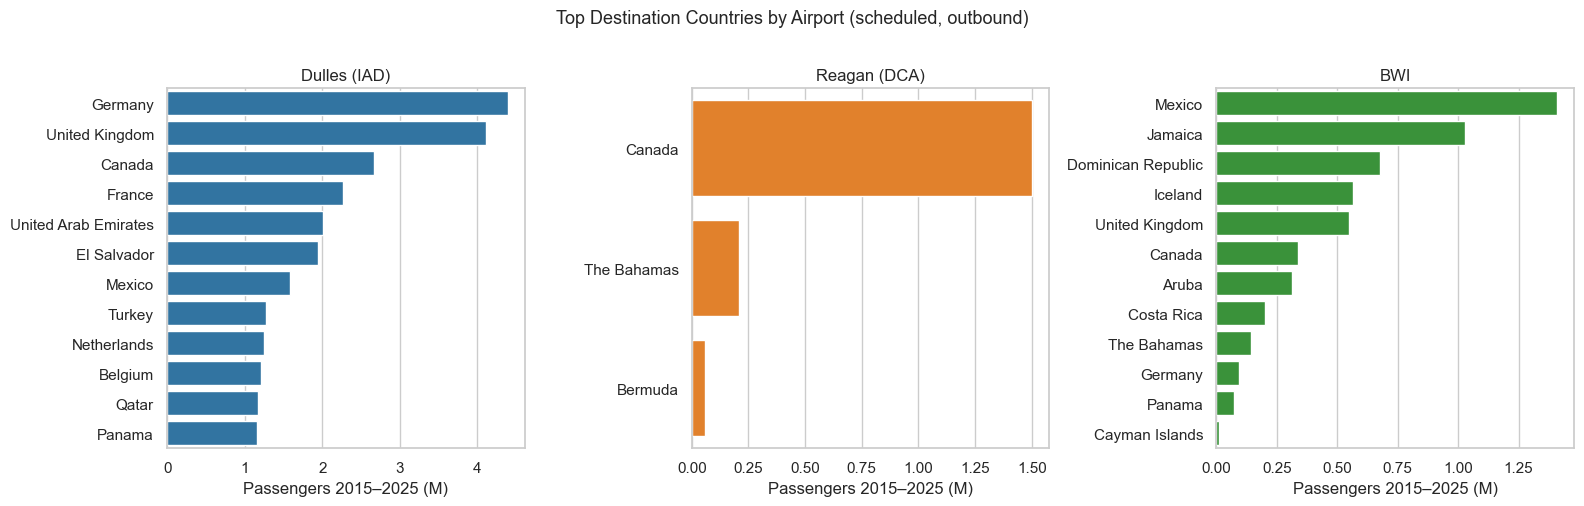

In [5]:
TOP_N = 12

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, airport in zip(axes, AIRPORTS):
    sub = outbound[outbound['ORIGIN'] == airport]
    top = (
        sub.groupby('DEST_COUNTRY_NAME')['PASSENGERS']
        .sum()
        .sort_values(ascending=False)
        .head(TOP_N)
    )
    sns.barplot(x=top.values / 1e6, y=top.index, ax=ax, color=COLORS[airport])
    ax.set_title(AIRPORT_NAMES[airport])
    ax.set_xlabel('Passengers 2015–2025 (M)')
    ax.set_ylabel('')

fig.suptitle('Top Destination Countries by Airport (scheduled, outbound)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Top individual routes per airport

Top 15 city-pair routes by cumulative passengers 2015–2025.

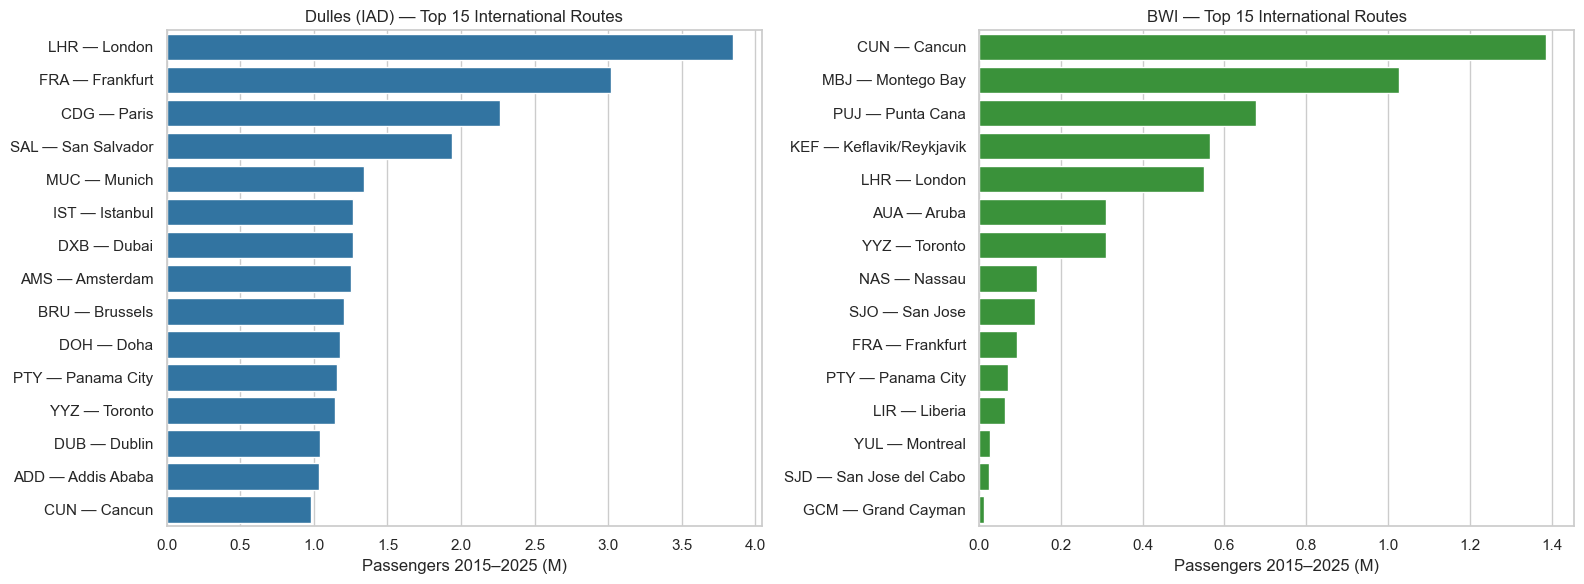

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, airport in zip(axes, ['IAD', 'BWI']):
    sub = outbound[outbound['ORIGIN'] == airport]
    top = (
        sub.groupby('DEST')['PASSENGERS']
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )
    # Annotate with city name
    city_map = sub.groupby('DEST')['DEST_CITY_NAME'].first()
    labels = [f"{dest} — {city_map.get(dest, dest).split(',')[0]}" for dest in top.index]
    sns.barplot(x=top.values / 1e6, y=labels, ax=ax, color=COLORS[airport])
    ax.set_title(f'{AIRPORT_NAMES[airport]} — Top 15 International Routes')
    ax.set_xlabel('Passengers 2015–2025 (M)')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

## 6. Carrier share of international routes per airport

IAD is a United hub; BWI is dominated by Southwest's leisure Caribbean routes.

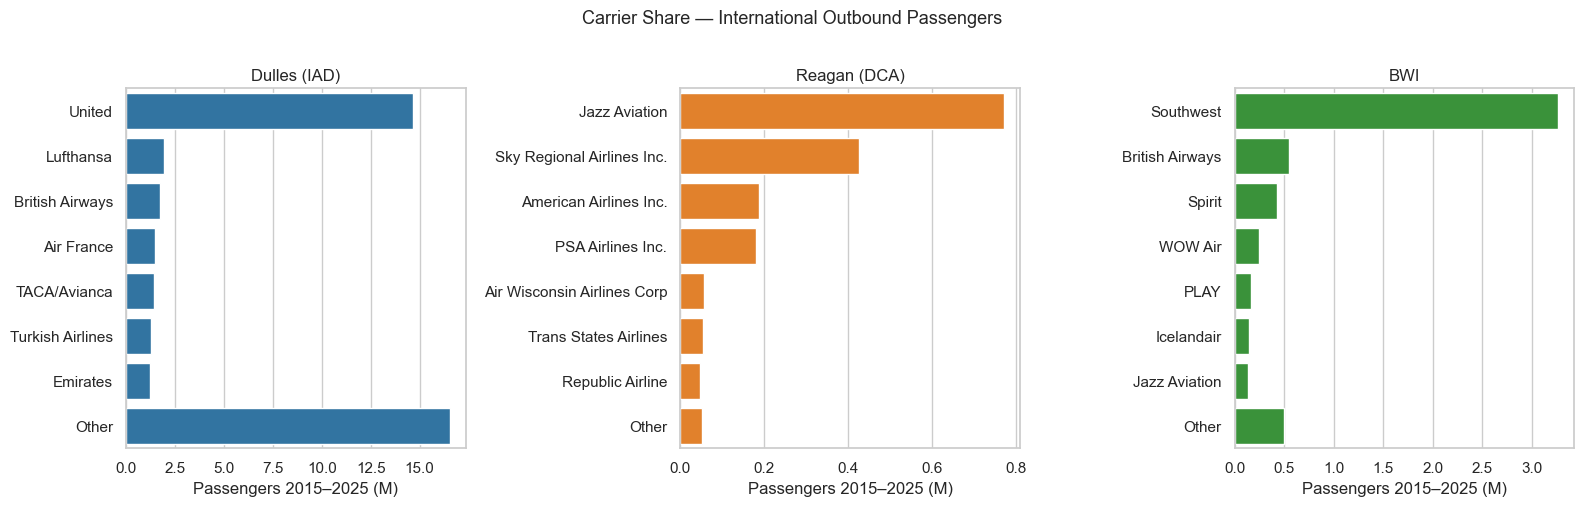

In [7]:
TOP_CARRIERS = 7

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, airport in zip(axes, AIRPORTS):
    sub = outbound[outbound['ORIGIN'] == airport]
    carr = sub.groupby('UNIQUE_CARRIER_NAME')['PASSENGERS'].sum().sort_values(ascending=False)
    top = carr.head(TOP_CARRIERS)
    other = carr.iloc[TOP_CARRIERS:].sum()
    if other > 0:
        top['Other'] = other

    # Shorten long names
    short = {
        'United Air Lines Inc.': 'United',
        'Lufthansa German Airlines': 'Lufthansa',
        'British Airways Plc': 'British Airways',
        'Compagnie Natl Air France': 'Air France',
        'Taca International Airlines': 'TACA/Avianca',
        'Turk Hava Yollari A.O.': 'Turkish Airlines',
        'Qatar Airways (Q.C.S.C)': 'Qatar Airways',
        'Compania Panamena (Copa)': 'Copa Airlines',
        'Ethiopian Airlines': 'Ethiopian',
        'Southwest Airlines Co.': 'Southwest',
        'Spirit Air Lines': 'Spirit',
        'WOW Air ehf': 'WOW Air',
        'Fly PLAY ehf': 'PLAY',
        'Air Canada Jazz': 'Air Canada Jazz',
        'Jazz Aviation LP': 'Jazz Aviation',
        'Emirates': 'Emirates',
    }
    top.index = [short.get(n, n) for n in top.index]

    sns.barplot(x=top.values / 1e6, y=top.index, ax=ax, color=COLORS[airport])
    ax.set_title(AIRPORT_NAMES[airport])
    ax.set_xlabel('Passengers 2015–2025 (M)')
    ax.set_ylabel('')

fig.suptitle('Carrier Share — International Outbound Passengers', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. COVID impact on international traffic

Indexed to 2019 = 100. Shows how differently the three airports recovered.

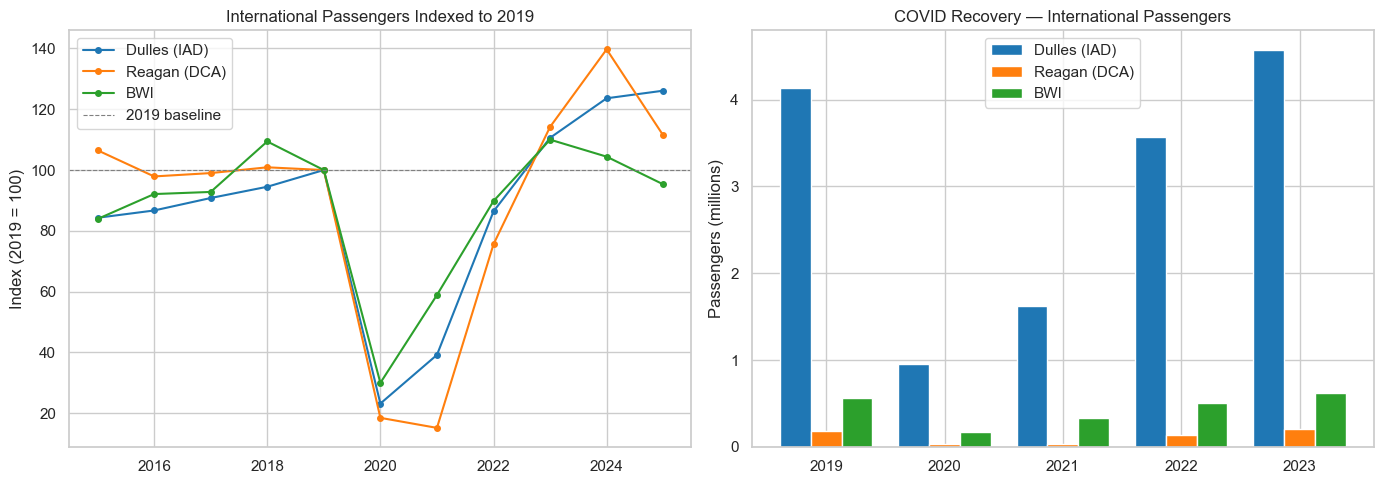

Recovery index (2019 = 100):
ORIGIN    BWI    DCA    IAD
YEAR                       
2019    100.0  100.0  100.0
2020     30.0   18.5   23.2
2021     58.9   15.2   39.2
2022     89.8   75.6   86.4
2023    110.0  114.2  110.6
2024    104.4  139.7  123.6
2025     95.3  111.4  126.1


In [8]:
pax_all = (
    outbound[outbound['YEAR'] <= 2025]
    .groupby(['YEAR', 'ORIGIN'])['PASSENGERS']
    .sum()
    .unstack()
    .fillna(0)
)
base_2019 = pax_all.loc[2019]
indexed = (pax_all / base_2019 * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for airport in AIRPORTS:
    ax.plot(indexed.index, indexed[airport], marker='o', ms=4,
            label=AIRPORT_NAMES[airport], color=COLORS[airport])
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8, label='2019 baseline')
ax.set_title('International Passengers Indexed to 2019')
ax.set_ylabel('Index (2019 = 100)')
ax.legend()

# Bar chart: 2019 vs 2020 vs 2021 vs 2022 vs 2023
ax = axes[1]
covid_years = [2019, 2020, 2021, 2022, 2023]
covid_data = pax_all.loc[covid_years] / 1e6
x = np.arange(len(covid_years))
width = 0.26
for i, airport in enumerate(AIRPORTS):
    ax.bar(x + i * width, covid_data[airport], width, label=AIRPORT_NAMES[airport], color=COLORS[airport])
ax.set_xticks(x + width)
ax.set_xticklabels(covid_years)
ax.set_title('COVID Recovery — International Passengers')
ax.set_ylabel('Passengers (millions)')
ax.legend()

plt.tight_layout()
plt.show()

print('Recovery index (2019 = 100):')
print(indexed.loc[2019:2025].to_string())

## 8. Seasonal pattern — monthly international passengers

Pre-COVID baseline (2015–2019 average) to isolate true seasonality from COVID noise.

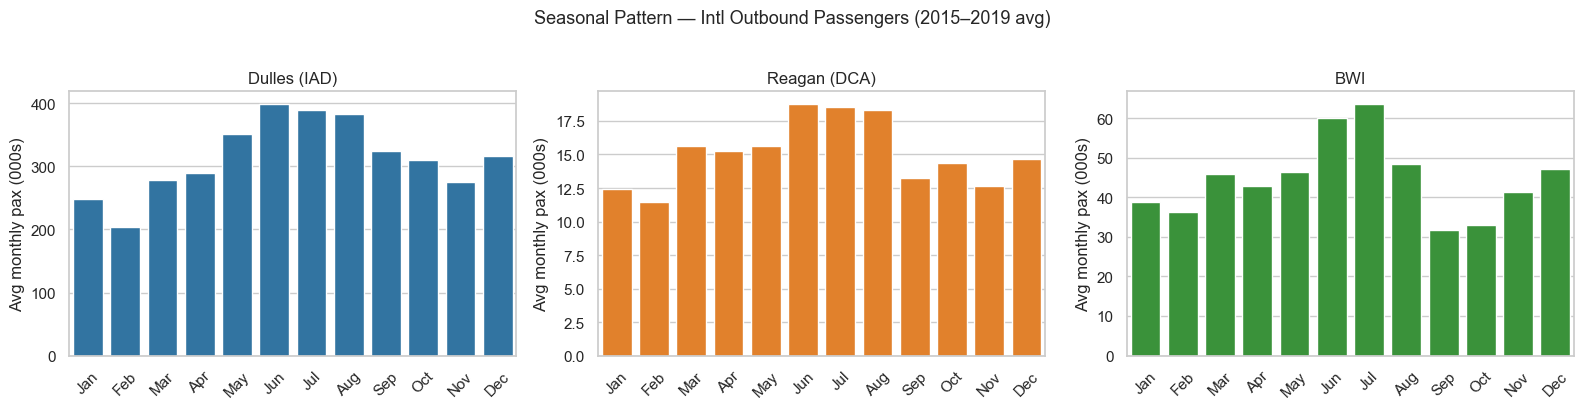

In [9]:
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

pre_covid = outbound[outbound['YEAR'].between(2015, 2019)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, airport in zip(axes, AIRPORTS):
    sub = pre_covid[pre_covid['ORIGIN'] == airport]
    monthly = sub.groupby('MONTH')['PASSENGERS'].sum() / 5  # avg per year
    monthly.index = MONTH_LABELS
    sns.barplot(x=monthly.index, y=monthly.values / 1e3, ax=ax, color=COLORS[airport])
    ax.set_title(AIRPORT_NAMES[airport])
    ax.set_xlabel('')
    ax.set_ylabel('Avg monthly pax (000s)')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Seasonal Pattern — Intl Outbound Passengers (2015–2019 avg)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. IAD carrier mix over time

Which carriers entered or exited IAD's international market across the decade?

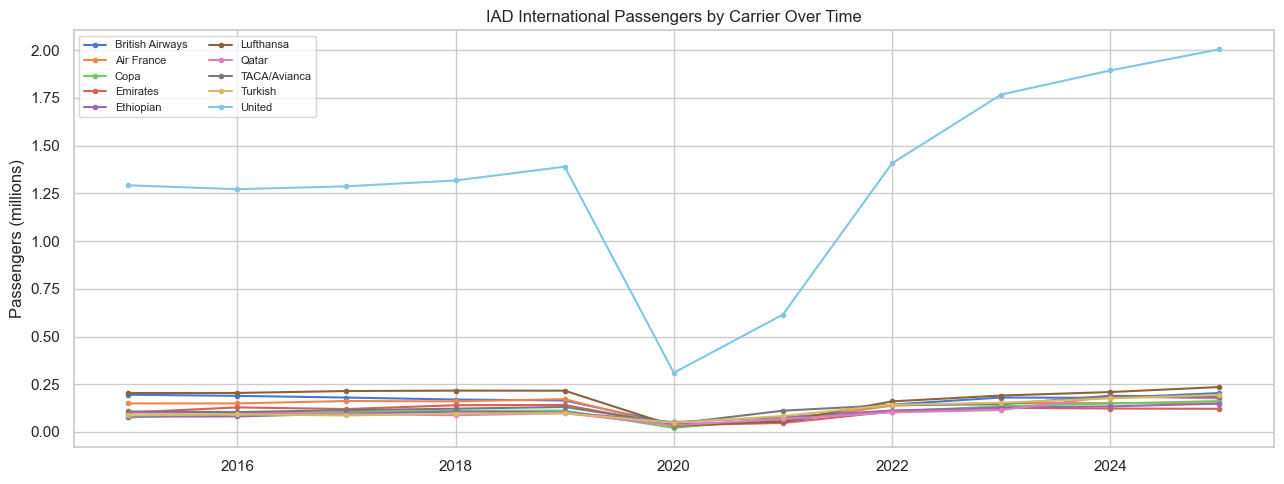

In [10]:
iad_out = outbound[(outbound['ORIGIN'] == 'IAD') & (outbound['YEAR'] <= 2025)]

# Top 10 carriers by total volume
top_carr = (
    iad_out.groupby('UNIQUE_CARRIER_NAME')['PASSENGERS']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

short = {
    'United Air Lines Inc.': 'United',
    'Lufthansa German Airlines': 'Lufthansa',
    'British Airways Plc': 'British Airways',
    'Compagnie Natl Air France': 'Air France',
    'Taca International Airlines': 'TACA/Avianca',
    'Turk Hava Yollari A.O.': 'Turkish',
    'Qatar Airways (Q.C.S.C)': 'Qatar',
    'Compania Panamena (Copa)': 'Copa',
    'Ethiopian Airlines': 'Ethiopian',
    'Emirates': 'Emirates',
}

carr_yr = (
    iad_out[iad_out['UNIQUE_CARRIER_NAME'].isin(top_carr)]
    .groupby(['YEAR', 'UNIQUE_CARRIER_NAME'])['PASSENGERS']
    .sum()
    .unstack()
    .fillna(0)
    .rename(columns=short)
)

fig, ax = plt.subplots(figsize=(13, 5))
carr_yr.div(1e6).plot(ax=ax, marker='o', ms=3, linewidth=1.5)
ax.set_title('IAD International Passengers by Carrier Over Time')
ax.set_ylabel('Passengers (millions)')
ax.set_xlabel('')
ax.legend(loc='upper left', ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## 10. Freight volume by airport × year

IAD handles substantial international airfreight; BWI and DCA handle almost none.

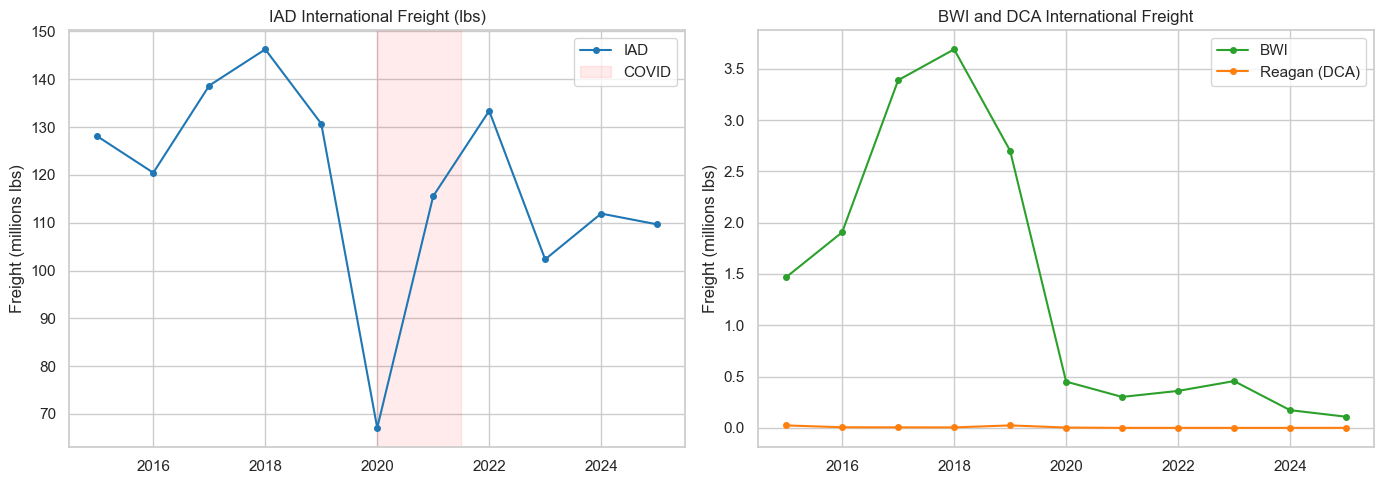


Freight (M lbs):
ORIGIN   BWI   DCA     IAD
YEAR                      
2015    1.47  0.02  128.08
2016    1.91  0.01  120.45
2017    3.39  0.01  138.69
2018    3.69  0.00  146.27
2019    2.70  0.02  130.72
2020    0.45  0.00   67.08
2021    0.30  0.00  115.55
2022    0.36  0.00  133.41
2023    0.46  0.00  102.33
2024    0.17  0.00  111.91
2025    0.11  0.00  109.65


In [11]:
freight_yr = (
    outbound[outbound['YEAR'] <= 2025]
    .groupby(['YEAR', 'ORIGIN'])['FREIGHT']
    .sum()
    .unstack()
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(freight_yr.index, freight_yr['IAD'] / 1e6, marker='o', ms=4,
        label='IAD', color=COLORS['IAD'])
ax.axvspan(2020, 2021.5, alpha=0.08, color='red', label='COVID')
ax.set_title('IAD International Freight (lbs)')
ax.set_ylabel('Freight (millions lbs)')
ax.legend()

ax = axes[1]
for airport in ['BWI', 'DCA']:
    ax.plot(freight_yr.index, freight_yr[airport] / 1e6, marker='o', ms=4,
            label=AIRPORT_NAMES[airport], color=COLORS[airport])
ax.set_title('BWI and DCA International Freight')
ax.set_ylabel('Freight (millions lbs)')
ax.legend()

plt.tight_layout()
plt.show()

print('\nFreight (M lbs):')
print((freight_yr / 1e6).round(2))

## 11. Summary table — key metrics per airport

Consolidated view of the international picture.

In [12]:
pre = outbound[outbound['YEAR'].between(2015, 2019)]
post = outbound[outbound['YEAR'].between(2023, 2025)]

rows = []
for airport in AIRPORTS:
    def stats(subset):
        s = subset[subset['ORIGIN'] == airport]
        pax = s['PASSENGERS'].sum()
        seats = s['SEATS'].sum()
        lf = pax / seats if seats > 0 else 0
        routes = s['DEST'].nunique()
        carriers = s['UNIQUE_CARRIER_NAME'].nunique()
        return {'pax_M': pax / 1e6, 'load_factor': lf, 'unique_routes': routes, 'carriers': carriers}

    pre_s = stats(pre)
    post_s = stats(post)
    rows.append({
        'Airport': AIRPORT_NAMES[airport],
        'Pre-COVID pax/yr (M)': f"{pre_s['pax_M'] / 5:.2f}",
        'Post-COVID pax/yr (M)': f"{post_s['pax_M'] / 3:.2f}",
        'Pre LF': f"{pre_s['load_factor']:.3f}",
        'Post LF': f"{post_s['load_factor']:.3f}",
        'Routes': pre_s['unique_routes'],
        'Carriers': pre_s['carriers'],
    })

summary = pd.DataFrame(rows).set_index('Airport')
print(summary.to_string())

             Pre-COVID pax/yr (M) Post-COVID pax/yr (M) Pre LF Post LF  Routes  Carriers
Airport                                                                                 
Dulles (IAD)                 3.77                  4.96  0.782   0.808      91        52
Reagan (DCA)                 0.18                  0.22  0.764   0.750       8        12
BWI                          0.54                  0.58  0.830   0.836      26        15
